In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

2026-06-24 10:34:40.135655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782297280.358642      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782297280.421850      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782297280.949167      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782297280.949242      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782297280.949245      16 computation_placer.cc:177] computation placer alr

In [2]:
base_path = "/kaggle/input/datasets/shuvoalok/raf-db-dataset"

print(os.listdir(base_path))

['test_labels.csv', 'DATASET', 'train_labels.csv']


In [3]:
dataset_path = base_path + "/DATASET"

print(os.listdir(dataset_path))

['test', 'train']


In [4]:
train_path = dataset_path + "/train"
test_path = dataset_path + "/test"

print("Train folders:", os.listdir(train_path))
print("Test folders:", os.listdir(test_path))

Train folders: ['7', '2', '5', '3', '1', '4', '6']
Test folders: ['7', '2', '5', '3', '1', '4', '6']


In [5]:
IMG_SIZE = 48
BATCH_SIZE = 32
EPOCHS = 20

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

num_classes = train_data.num_classes
print("Classes:", train_data.class_indices)

Found 9819 images belonging to 7 classes.
Found 2452 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
Classes: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6}


In [7]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

2026-06-24 10:35:13.327698: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,423 (1.36 MB)

 Trainable params: 356,423 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 100s 319ms/step - accuracy: 0.3910 - loss: 1.6391 - val_accuracy: 0.4197 - val_loss: 1.5109
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 37s 120ms/step - accuracy: 0.4559 - loss: 1.4762 - val_accuracy: 0.5420 - val_loss: 1.3648
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - accuracy: 0.5212 - loss: 1.3090 - val_accuracy: 0.5648 - val_loss: 1.2063
Epoch 4/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 37s 120ms/step - accuracy: 0.5602 - loss: 1.2057 - val_accuracy: 0.5942 - val_loss: 1.1161
Epoch 5/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 35s 115ms/step - accuracy: 0.5872 - loss: 1.1414 - val_accuracy: 0.6264 - val_loss: 1.0680
Epoch 6/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - accuracy: 0.6071 - loss: 1.0919 - val_accuracy: 0.6493 - val_loss: 0.9751
Epoch 7/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 36s 118ms/step - accuracy: 0.6281 - loss: 1.0410 - val_accuracy: 0.6550 - val_loss: 0.9926
Epoch 8/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.6371 - loss: 

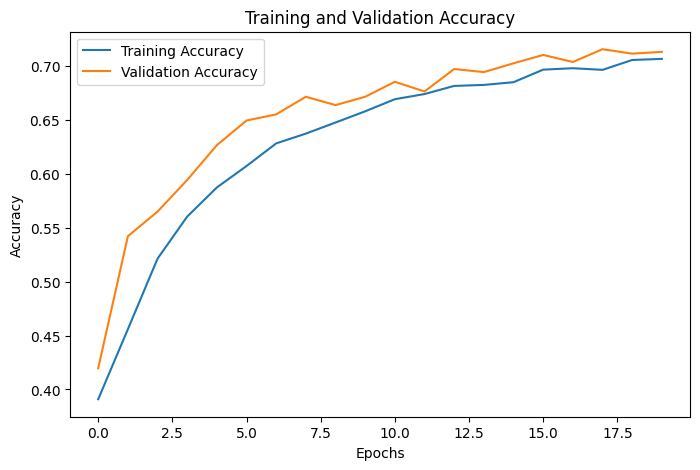

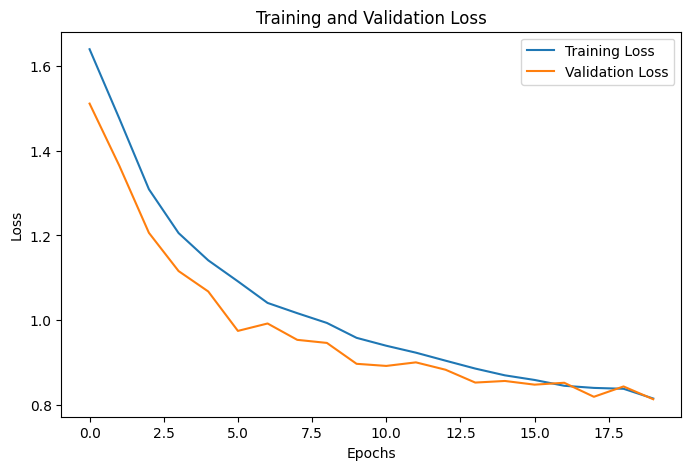

In [9]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [10]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 250ms/step - accuracy: 0.7350 - loss: 0.7543
Test Loss: 0.7542770504951477
Test Accuracy: 0.7350065112113953


96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step
              precision    recall  f1-score   support

           1       0.82      0.64      0.72       329
           2       0.82      0.38      0.52        74
           3       0.63      0.17      0.27       160
           4       0.86      0.89      0.87      1185
           5       0.59      0.67      0.63       478
           6       0.63      0.59      0.61       162
           7       0.63      0.77      0.69       680

    accuracy                           0.74      3068
   macro avg       0.71      0.59      0.62      3068
weighted avg       0.74      0.74      0.73      3068



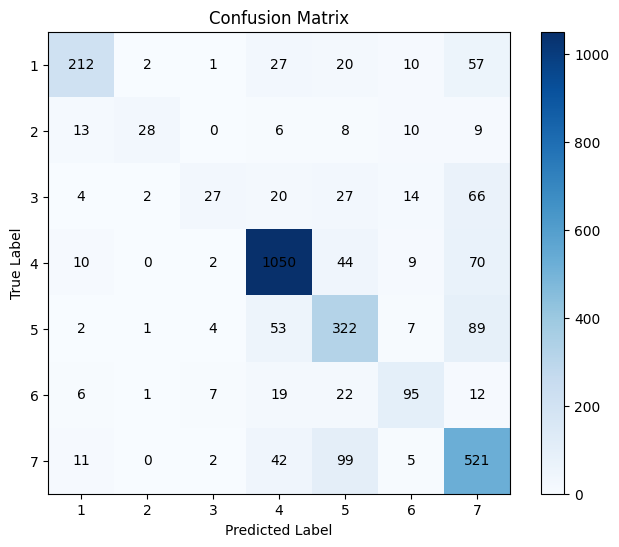

In [11]:
test_data.reset()

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

class_names = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [12]:
model.save("/kaggle/working/facial_expression_cnn_model.keras")
print("Model saved successfully")

Model saved successfully
